# Evaluating Evolutionary Algorithms for Optimization Tasks (Feature Selection & Hyper-parameter Tuning)

This notebook explores and evaluates three evolutionary optimization algorithms: Particle Swarm Optimization (PSO), Genetic Algorithms (GA), and Evolutionary Strategies (ES), across distinct machine learning tasks. The goal is to compare their operational behavior, convergence characteristics, and computational efficiency when applied to black-box optimization problems. Each algorithm is implemented in Python from first principles and evaluated on two case studies: (1) feature selection for logistic regression and (2) hyperparameter tuning of a small neural network. Through these experiments, performance is assessed using metrics such as convergence speed, solution quality, robustness, and runtime; providing a practical comparison of how each algorithm balances exploration and exploitation in real-world optimization scenarios.

## Imports

In [2]:
# --- imports ---
import os
import gc
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from time import perf_counter
warnings.filterwarnings("ignore")

# Imports
import time, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable, Tuple, Dict, List
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier


### Feature Selection and Hyper-parameter tuning functions for Evolutionary Algorithm Comparison 

In [5]:
# Feature Selection function
def feature_selection_objective_factory(X, y, sparsity_lambda=0.01, random_state=42):
    # Fixed split for speed, could implement CV if desired
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=random_state
    )
    clf = LogisticRegression(max_iter=500)

    def obj(z: np.ndarray) -> float:
        mask = (z > 0.5)
        if mask.sum() == 0:
            return 1.0
        Xtr = X_tr[:, mask]
        Xva = X_va[:, mask]
        try:
            clf.fit(Xtr, y_tr)
            acc = clf.score(Xva, y_va)
        except Exception:
            return 1.0
        # Minimize: (1-acc) + small sparsity penalty
        return (1.0 - acc) + sparsity_lambda * (mask.mean())
    return obj

# MLP Hyperparameter function
def mlp_hyperparam_objective_factory(X, y, random_state=42):
    # Subsample for speed + fixed split
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=random_state
    )

    def clamp(v, lo, hi):
        return max(lo, min(hi, v))

    def obj(z: np.ndarray) -> float:
        # z = [log10_alpha, log10_lr, units, layers]
        log10_alpha = clamp(float(z[0]), -6, -1)
        log10_lr    = clamp(float(z[1]), -4, -1)
        units       = int(round(clamp(float(z[2]), 16, 96)))
        layers_raw  = clamp(float(z[3]), 1, 2)
        layers      = 1 if layers_raw < 1.5 else 2

        hidden = (units,) if layers == 1 else (units, units)
        clf = MLPClassifier(
            hidden_layer_sizes=hidden,
            activation="relu",
            solver="adam",
            alpha=10**log10_alpha,
            learning_rate_init=10**log10_lr,
            max_iter=60,             
            early_stopping=True,
            n_iter_no_change=5,
            validation_fraction=0.15,
            random_state=0,
            verbose=False
        )
        try:
            clf.fit(X_tr, y_tr)
            acc = clf.score(X_va, y_va)
        except Exception:
            return 1.0
        return 1.0 - acc
    return obj

Two optimization objectives above were defined to evaluate the performance of Particle Swarm Optimization (PSO), Genetic Algorithms (GA), and Evolutionary Strategies (ES). The first objective focuses on feature selection for the Breast Cancer dataset, where each optimizer searches for the best subset of input features to maximize classification accuracy while minimizing model complexity. Each candidate solution is represented as a real-valued vector in [0,1]^d, thresholded to determine which features were included. The fitness function combined model error (1 - accuracy) with a small sparsity penalty, encouraging succinct yet accurate subsets.

The second objective addresses hyperparameter tuning of a small neural network (MLP) on the Digits dataset. The optimizers search over continuous and discrete parameters including regularization strength (α), learning rate, number of hidden units, and number of layers to minimize validation loss. By encoding both continuous and discrete choices as real-valued decision variables, this objective provides a flexible black-box optimization problem suitable for all three evolutionary methods tested.

### Particle Swarm Optimization Algorithm from first principles

In [9]:
# PSO 
@dataclass
class PSOConfig:
    n_particles: int   # swarm size (population)
    n_iters: int       # optimization iterations (generations)
    w: float = 0.7     # inertia weight (higher -> particles keep moving (explore); lower -> they slow down (exploit).
    c1: float = 1.5    # cognitive coefficient (pull toward particle’s own best)
    c2: float = 1.5    # social coefficient (pull toward global best)
    bounds: Tuple[np.ndarray, np.ndarray] = None  # [lo, hi] per dimension
    
def pso_optimize(f, dim, cfg, seed=0):
    rng = np.random.default_rng(seed)
    lo, hi = cfg.bounds if cfg.bounds is not None else (np.zeros(dim), np.ones(dim))
    # Random positions within bounds: shape (n_particles, dim)
    X = rng.uniform(lo, hi, size=(cfg.n_particles, dim))
    # Small random initial velocities
    V = rng.uniform(-(hi-lo), (hi-lo), size=(cfg.n_particles, dim)) * 0.1

    pbest = X.copy()
    pbest_val = np.array([f(x) for x in X]) # each particle’s best-so-far position/value
    g_idx = int(np.argmin(pbest_val))
    gbest = pbest[g_idx].copy(); gbest_val = float(pbest_val[g_idx]) # Global Best Particle
    history = [gbest_val] # tracks best-so-far loss per iteration for convergence plots
    evals = len(pbest_val) # Total objective evals (proxy for compute cost)
    iter_of_best = 0  # Records the last time the global best improved (proxy for convergence speed)

    for t in range(cfg.n_iters):
        r1 = rng.random((cfg.n_particles, dim)) # Insert randomness per particle/dimension
        r2 = rng.random((cfg.n_particles, dim))

        # Velocity update = inertia + cognitive pull + social pull
        V = cfg.w*V + cfg.c1*r1*(pbest - X) + cfg.c2*r2*(gbest - X)
        # Position update + bounding to keep feasibility
        X = np.clip(X + V, lo, hi)
        # Evaluate new positions
        vals = np.array([f(x) for x in X])
        evals += len(vals)
        # Update personal bests where improved
        improved = vals < pbest_val
        pbest[improved] = X[improved]
        pbest_val[improved] = vals[improved]
        # Possibly update global best
        g_idx = int(np.argmin(pbest_val))
        if pbest_val[g_idx] < gbest_val:
            gbest_val = float(pbest_val[g_idx])
            gbest = pbest[g_idx].copy()
            iter_of_best = t + 1
        # Record convergence
        history.append(gbest_val)

    return {
        "best_x": gbest,           # best solution vector found
        "best_val": gbest_val,     # its objective value (lower is better)
        "history": history,        # best-so-far per iteration (for plots)
        "evals": evals,            # total f-calls (computational demand)
        "iter_of_best": iter_of_best  # when the last improvement occurred
    }

The PSO algorithm is a population-based optimizer that models a swarm of particles exploring a search space. Each particle represents a potential solution and moves according to its own experience and the knowledge of the swarm’s best performer. At each iteration, particle velocities are updated using three components: inertia (momentum from previous motion), a cognitive term (attraction to the particle’s personal best), and a social term (attraction to the global best). Positions are then updated and evaluated on the objective function. Over time, this cooperative mechanism allows the swarm to balance exploration of new regions with exploitation of known good solutions, converging toward an optimal or near-optimal point in the search space.

### Genetic Algorithm from first principles

In [23]:
# GA 
@dataclass
# Of the variables below, Crossover and Elitism control exploitation, while mutation and sigma control exploration
class GAConfig:
    pop_size: int      # number of individuals per generation
    n_gens: int        # how many generations to evolve
    p_crossover: float = 0.8 # chance two parents recombine
    p_mutation: float = 0.4  # chance a child is mutated
    sigma: float = 0.25     # mutation std (as a fraction of variable range)
    bounds: Tuple[np.ndarray, np.ndarray] = None  # per-dimension [lo, hi]
    elitism: int = 2   # how many top individuals are copied directly

def ga_optimize(f: Callable[[np.ndarray], float], dim: int, cfg: GAConfig, seed: int = 0) -> Dict:
    rng = np.random.default_rng(seed)
    lo, hi = cfg.bounds if cfg.bounds is not None else (np.zeros(dim), np.ones(dim)) # Dimension Bounds
    span = hi - lo

    # Start with a diverse population sampled uniformly in bounds and evluate them
    def init_pop(): return rng.uniform(lo, hi, size=(cfg.pop_size, dim))
    def evaluate(P):   return np.array([f(ind) for ind in P])
    
    # Sample k candidates and pick the best (larger k = stronger pressure)
    def select_tourn(P, fit, k=3):
        idxs = rng.integers(0, len(P), size=k) 
        return P[idxs[np.argmin(fit[idxs])]].copy()

    # Produce a child between 2 parents per dimensions 
    def crossover(a, b):
        if rng.random() < cfg.p_crossover:
            alpha = rng.random(dim) 
            return alpha*a + (1-alpha)*b
        return a.copy()

    # Add gaussian perturbations to keep exploring new areas
    # sigma * span scales noise to the variable ranges
    def mutate(ind):
        if rng.random() < cfg.p_mutation:
            ind = ind + rng.normal(0, cfg.sigma, size=dim) * span
        return np.clip(ind, lo, hi)

    P = init_pop()
    fit = evaluate(P)
    evals = len(fit)

    # Track the history of evaluations, and when the last global improvement was recorded
    best_idx = int(np.argmin(fit)) 
    best = P[best_idx].copy() 
    best_val = float(fit[best_idx])
    iter_of_best = 0 
    history = [best_val]

    # Elitism protects the very best individuals from being lost
    # New generation is elites + offspring from the selection->crossover->mutation process
    for g in range(cfg.n_gens):
        elite = P[np.argsort(fit)[:cfg.elitism]].copy()
        kids = []
        while len(kids) < cfg.pop_size - cfg.elitism:
            p1, p2 = select_tourn(P, fit), select_tourn(P, fit)
            child = mutate(crossover(p1, p2)) 
            kids.append(child)
        P = np.vstack([elite, np.array(kids)])
        fit = evaluate(P) 
        evals += len(fit)
        idx = int(np.argmin(fit))
        if fit[idx] < best_val:
            best_val = float(fit[idx]) 
            best = P[idx].copy() 
            iter_of_best = g + 1
        history.append(best_val)

    return {
        "best_x": best,           # best solution vector found
        "best_val": best_val,     # its objective value (lower is better)
        "history": history,        # best-so-far per iteration (for plots)
        "evals": evals,            # total f-calls (computational demand)
        "iter_of_best": iter_of_best  # when the last improvement occurred
    }

This GA algorithm maintains a population of candidate solutions and iteratively evolves them through selection, crossover, mutation, and elitism. In each generation, it evaluates fitness for all individuals (minimization), copies the top elitism performers unchanged, then fills the rest of the next population by repeatedly selecting parents via tournament selection, creating children with a crossover (blending parent genes), and injecting diversity through Gaussian mutation scaled to each variable’s range (and clipped to bounds). The algorithm records the best-so-far value each generation, the iteration of last improvement, and the total evaluations for compute accounting. Key trade-offs are tuned by p_crossover and p_mutation (exploration vs. exploitation), sigma (mutation step size), elitism, and pop_size/n_gens (search breadth and time budget).

### Evolutionary Strategy Algorithm from first principles

In [27]:
# ES (μ+λ) with self-adaptive σ
@dataclass
# Common rule of thumb: λ ≳ 3×μ for healthy exploration
class ESConfig:
    mu: int          # number of parents retained each generation (μ)
    lam: int         # number of offspring generated per generation (λ)
    n_gens: int      # number of generations
    bounds: Tuple[np.ndarray, np.ndarray] = None  # per-dimension [lo, hi]

# Start with mu parents uniformly samples from search space and give each a mutation vector of step size sigma
def es_optimize(f: Callable[[np.ndarray], float], dim: int, cfg: ESConfig, seed: int = 0) -> Dict:
    rng = np.random.default_rng(seed)
    lo, hi = cfg.bounds if cfg.bounds is not None else (np.zeros(dim), np.ones(dim))
    span = hi - lo
    # Tau and Tau_p represent learning rates for self-adaptation (global and coordinate-wise)
    tau_p = 1 / math.sqrt(2*dim) 
    tau = 1 / math.sqrt(2*math.sqrt(dim))
    
    X = rng.uniform(lo, hi, size=(cfg.mu, dim))  # parent solutions
    S = np.full((cfg.mu, dim), 0.3)              # per-dimension step sizes σ

    # Calculating mutation step size per-offspring allows sigma to start high, and end small
    # High exploration early, high exploitation later
    # log-normal updates ensure sigma stays positive and evolves smoothly
    def mutate(x, s):
        n0 = rng.normal(0, 1) 
        n = rng.normal(0, 1, size=dim)
        s_new = np.clip(s * np.exp(tau_p*n0 + tau*n), 1e-6, 1.0)
        x_new = np.clip(x + rng.normal(0, 1, size=dim)*(s_new*span), lo, hi)
        return x_new, s_new

    def evaluate(P): return np.array([f(ind) for ind in P])

    fit = evaluate(X) 
    evals = len(fit)
    best_idx = int(np.argmin(fit)) 
    best_x = X[best_idx].copy() 
    best_val = float(fit[best_idx])
    iter_of_best = 0; history = [best_val]

    for g in range(cfg.n_gens):
        # Generate λ offspring by mutating random parents
        off_X, off_S = [], []
        for _ in range(cfg.lam):
            i = rng.integers(0, cfg.mu) # Select a parent
            x_c, s_c = mutate(X[i], S[i])
            off_X.append(x_c) 
            off_S.append(s_c)
        off_X, off_S = np.array(off_X), np.array(off_S)
        fit_off = evaluate(off_X) 
        evals += len(fit_off)

        # (μ+λ) is elitist: parents can survive alongside offspring if they're among the best mu
        # Alternatively, we choose mu from offspring only 
        all_X = np.vstack([X, off_X]) 
        all_S = np.vstack([S, off_S])
        all_f = np.hstack([fit, fit_off])
        idxs = np.argsort(all_f)[:cfg.mu]
        X, S, fit = all_X[idxs], all_S[idxs], all_f[idxs]

        if fit[0] < best_val:
            best_val = float(fit[0]) 
            best_x = X[0].copy() 
            iter_of_best = g + 1
        history.append(best_val)

    return {
        "best_x": best_x,           # best solution vector found
        "best_val": best_val,     # its objective value (lower is better)
        "history": history,        # best-so-far per iteration (for plots)
        "evals": evals,            # total f-calls (computational demand)
        "iter_of_best": iter_of_best  # when the last improvement occurred
    }

The Evolutionary Strategy (ES) algorithm optimizes a population of candidate solutions through iterative mutation, evaluation, and selection. Each solution (parent) carries its own adaptive mutation step size (σ), which evolves alongside the solution parameters using log-normal self-adaptation, allowing the algorithm to automatically adjust its exploration scale over time. In each generation, μ parents produce λ offspring by applying Gaussian perturbations scaled by their individual σ values. All candidates (parents + offspring) are then evaluated, and the best μ individuals are retained for the next generation, ensuring elitism and steady convergence. This self-adaptive mechanism enables ES to dynamically balance exploration and exploitation, making it particularly effective for smooth, continuous, and high-dimensional optimization problems where gradient information is unavailable.

### Feature Ranking Case Study

In [29]:
bc = load_breast_cancer()
X_bc = StandardScaler().fit_transform(bc.data) # Standardize feature matrix
y_bc = bc.target # Binary Target (malignant vs benign)
d_bc = X_bc.shape[1] # Number of features, used to size the optimizer model search space
bounds_fs = (np.zeros(d_bc), np.ones(d_bc)) # lower/upper limits for each feature
fs_obj = feature_selection_objective_factory(X_bc, y_bc, sparsity_lambda=0.01, random_state=0)

# Basic PSO/GA/ES configurations to serve as a benchmark
pso_fs = PSOConfig(n_particles=10, n_iters=8, bounds=bounds_fs)
ga_fs  = GAConfig(pop_size=14, n_gens=8, bounds=bounds_fs, p_mutation=0.5, sigma=0.25, elitism=2)
es_fs  = ESConfig(mu=6, lam=16, n_gens=8, bounds=bounds_fs)

# Standardized evaluation loop that runs each optimizer under the same conditions
# Objective = function to minimize; in this case feature-selection loss
# dim = # of features
# cfgs = dictionary mapping alg names to their functions above
def run_task(task_name, objective, dim, cfgs, seeds=(0,1)):
    rows, histories = [], {k: [] for k in cfgs}
    for algo, (fn, cfg) in cfgs.items():
        for i, s in enumerate(seeds):
            t0 = time.time()
            res = fn(objective, dim, cfg, seed=s)
            dt = time.time() - t0
            # Each run records best objective value achieved, the iteration of the best run, 
            # the number of total calls, and total runtime
            rows.append({
                "Task": task_name, "Algorithm": algo, "Run": i+1,
                "Best_Loss": res["best_val"],
                "Iter_of_Best": res["iter_of_best"],
                "Evaluations": res["evals"],
                "Runtime_s": dt
            })
            histories[algo].append(res["history"])
    return pd.DataFrame(rows), histories

# Executes PSO/GA/ES sequantially, each twice 
# Returns a raw dataframe of run-level metrics and a dictionary of convergence curves for each model
df_fs, hist_fs = run_task(
    "Feature Selection (Breast Cancer)", fs_obj, d_bc,
    {"PSO": (pso_optimize, pso_fs), "GA": (ga_optimize, ga_fs), "ES": (es_optimize, es_fs)}
)

# Aggregates replicate runs to compute means and std deviations of performance metrics
def summarize(df):
    return (df.groupby(["Task","Algorithm"])
              .agg(Mean_Best_Loss=("Best_Loss","mean"),
                   Std_Best_Loss=("Best_Loss","std"),
                   Mean_Iter_of_Best=("Iter_of_Best","mean"),
                   Mean_Evaluations=("Evaluations","mean"),
                   Mean_Runtime_s=("Runtime_s","mean"),
                   Std_Runtime_s=("Runtime_s","std"),
                   Runs=("Run","count"))
              .reset_index())

summary_fs = summarize(df_fs)
# Adds a proxy for accuracy since the real objective is a minimization problem (minimizing loss)
summary_fs["Accuracy_proxy"] = 1.0 - summary_fs["Mean_Best_Loss"]
summary_fs

,Task,Algorithm,Mean_Best_Loss,Std_Best_Loss,Mean_Iter_of_Best,Mean_Evaluations,Mean_Runtime_s,Std_Runtime_s,Runs,Accuracy_proxy
0,Feature Selection (Breast Cancer),ES,0.025135,0.003192,4.5,134.0,0.105339,0.000750,2,0.974865
1,Feature Selection (Breast Cancer),GA,0.028058,0.000471,6.0,126.0,0.097926,0.003876,2,0.971942
2,Feature Selection (Breast Cancer),PSO,0.030649,0.002721,2.0,90.0,0.082524,0.022550,2,0.969351


Across the feature selection task, all three evolutionary algorithms successfully identified feature subsets yielding high classification accuracy (>96%), but they differed in convergence dynamics and computational efficiency. The Evolutionary Strategy (ES) achieved the lowest mean loss (0.025) and highest accuracy proxy (97.5%), indicating its self-adaptive mutation scheme effectively balanced exploration and exploitation. It converged in roughly 4–5 iterations and required moderate computational effort, suggesting that ES efficiently refined solutions without excessive search overhead.

The Genetic Algorithm (GA) followed closely, reaching a mean accuracy of 97.2% with very low variability between runs, demonstrating strong consistency and robustness. However, it required slightly more generations (mean iteration 6) to find its best solution. In contrast, Particle Swarm Optimization (PSO) achieved the fastest convergence and lowest runtime (≈0.08 s) but at the cost of a slightly higher final loss and lower accuracy (96.9%), consistent with premature convergence toward local optima. Overall, ES provided the best trade-off between solution quality and computational efficiency, GA excelled in stability, and PSO favored speed; highlighting the classic trade-offs among exploration, exploitation, and runtime efficiency in evolutionary optimization.

Below is a plot showing the convergence profiles of the three algorithms. It's easy to see how fast Particle Swarm Optimization was able to converge on it's optimal answer, despite it not being the global minimum solution.

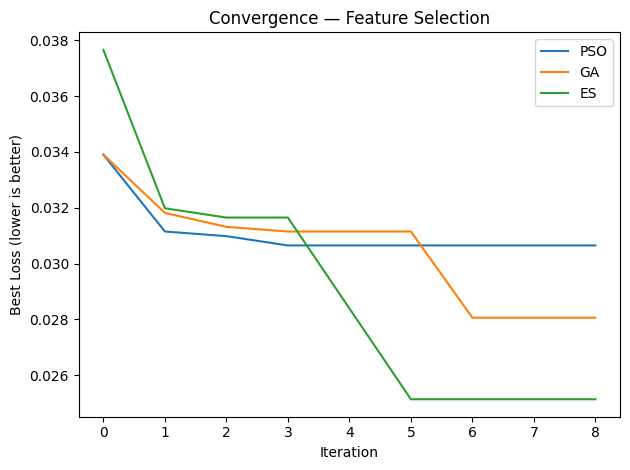

In [31]:
def plot_histories(title, histories):
    plt.figure()
    for algo, runs in histories.items():
        maxlen = max(len(h) for h in runs)
        arr = []
        for h in runs:
            if len(h) < maxlen: h = h + [h[-1]]*(maxlen-len(h))
            arr.append(h)
        arr = np.array(arr)
        plt.plot(arr.mean(axis=0), label=algo)
    plt.xlabel("Iteration"); plt.ylabel("Best Loss (lower is better)")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_histories("Convergence — Feature Selection", hist_fs)

### Hyper-parameter Tuning Study

In [36]:
# Data
digits = load_digits()
X_dig = StandardScaler().fit_transform(digits.data); y_dig = digits.target

hp_bounds = (np.array([-6., -4., 16., 1.]), np.array([-1., -1., 96., 2.]))
hp_obj = mlp_hyperparam_objective_factory(X_dig, y_dig, random_state=0)

# Leverage the same optimization algorithm setpoints as the feature ranking study
pso_hp = PSOConfig(n_particles=10, n_iters=8, bounds=hp_bounds)
ga_hp  = GAConfig(pop_size=14, n_gens=8, bounds=hp_bounds, p_mutation=0.5, sigma=0.25, elitism=2)
es_hp  = ESConfig(mu=6, lam=16, n_gens=8, bounds=hp_bounds)

df_hp, hist_hp = run_task(
    "MLP Hyperparameter Tuning (Digits)", hp_obj, 4,
    {"PSO": (pso_optimize, pso_hp), "GA": (ga_optimize, ga_hp), "ES": (es_optimize, es_hp)}
)

summary_hp = summarize(df_hp)
summary_hp["Accuracy_proxy"] = 1.0 - summary_hp["Mean_Best_Loss"]
summary_hp

,Task,Algorithm,Mean_Best_Loss,Std_Best_Loss,Mean_Iter_of_Best,Mean_Evaluations,Mean_Runtime_s,Std_Runtime_s,Runs,Accuracy_proxy
0,MLP Hyperparameter Tuning (Digits),ES,0.019444,0.001309,3.5,134.0,25.354269,5.287930,2,0.980556
1,MLP Hyperparameter Tuning (Digits),GA,0.022222,0.002619,2.0,126.0,17.792302,0.759217,2,0.977778
2,MLP Hyperparameter Tuning (Digits),PSO,0.021296,0.001309,2.5,90.0,9.671057,0.765109,2,0.978704


In this hyperparameter tuning study, all three evolutionary algorithms effectively optimized the MLP’s key parameters to achieve high classification accuracy (>97%), though they exhibited distinct efficiency and convergence profiles. The Evolutionary Strategy (ES) again delivered the best overall performance, achieving the lowest mean loss (0.0194) and highest mean accuracy proxy (98.1%). Its adaptive mutation mechanism allowed it to explore a diverse set of hyperparameter combinations while efficiently refining step sizes, converging in approximately 3-4 iterations. Despite having the highest average runtime (≈25 s), ES demonstrated a strong ability to fine-tune hyperparameters for robust model generalization.

The Genetic Algorithm (GA) followed closely, attaining a mean accuracy of 97.8% while maintaining low variance across runs. Its shorter runtime (≈18 s) and fewer iterations to convergence (≈2) highlight its efficiency in sampling and recombining promising hyperparameter sets. Particle Swarm Optimization (PSO) once again showed the fastest runtime (≈9.7 s) and relatively quick convergence, though with a slightly higher mean loss and slightly lower accuracy (97.9%). This pattern mirrors the feature-selection experiment: PSO prioritized rapid exploitation, while ES maintained a deeper, more adaptive search leading to superior accuracy. Overall, ES proved most effective for complex, continuous hyperparameter spaces, GA balanced stability and efficiency, and PSO offered computational speed with near-competitive accuracy.

Once again when referring to our convergence graph it's clear that the Evolutionary Strategy algorithm is able to both converge quickly and arrive arrive at the lowest loss value rather than a local minimum.

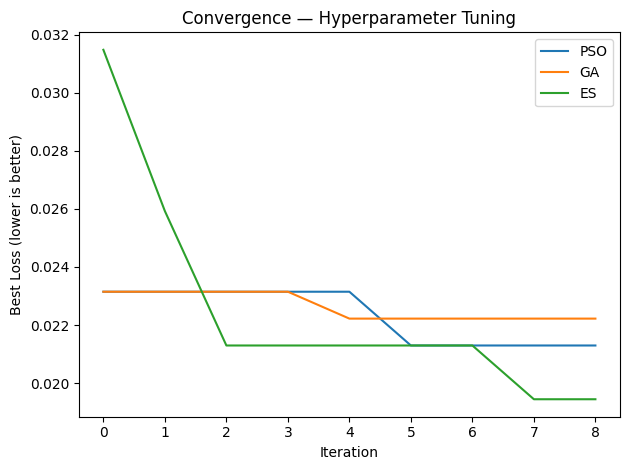

In [40]:
plot_histories("Convergence — Hyperparameter Tuning", hist_hp)

### Final Results Summary

In [42]:
results_all = pd.concat([summary_fs, summary_hp], ignore_index=True)
results_all[["Task","Algorithm","Accuracy_proxy","Mean_Iter_of_Best","Mean_Evaluations","Mean_Runtime_s","Std_Best_Loss","Runs"]]

,Task,Algorithm,Accuracy_proxy,Mean_Iter_of_Best,Mean_Evaluations,Mean_Runtime_s,Std_Best_Loss,Runs
0,Feature Selection (Breast Cancer),ES,0.974865,4.5,134.0,0.105339,0.003192,2
1,Feature Selection (Breast Cancer),GA,0.971942,6.0,126.0,0.097926,0.000471,2
2,Feature Selection (Breast Cancer),PSO,0.969351,2.0,90.0,0.082524,0.002721,2
3,MLP Hyperparameter Tuning (Digits),ES,0.980556,3.5,134.0,25.354269,0.001309,2
4,MLP Hyperparameter Tuning (Digits),GA,0.977778,2.0,126.0,17.792302,0.002619,2
5,MLP Hyperparameter Tuning (Digits),PSO,0.978704,2.5,90.0,9.671057,0.001309,2


Across both the feature selection and hyperparameter tuning studies, all three evolutionary algorithms demonstrated strong optimization capability, achieving high accuracies (96–98%) with relatively low computational overhead. The Evolutionary Strategy (ES) consistently delivered the best overall performance, achieving the highest accuracy proxies in both tasks (97.5% and 98.1%). The Genetic Algorithm (GA) followed closely with competitive accuracy and minimal variability between runs, reflecting reliable yet slightly slower convergence. Meanwhile, Particle Swarm Optimization (PSO) excelled in runtime efficiency and fast convergence but occasionally plateaued early, resulting in marginally lower final accuracies. Collectively, these results highlight ES as the most robust and generalizable optimizer for continuous, complex search spaces, GA as a strong and stable alternative, and PSO as the best option when computational speed is prioritized over marginal accuracy gains.